In [10]:
import numpy as np
import pandas as pd
from tensorflow import keras

In [16]:
df = pd.read_csv("/content/dataset.csv")

In [17]:
x = df["text"]
y = df["label"]

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
v= TfidfVectorizer()
x = v.fit_transform(x)

In [19]:
from sklearn.model_selection import train_test_split as tts
X_train , X_test , Y_train , Y_test = tts(x ,y, test_size=0.2)

In [20]:
X_train.shape

(2400, 211)

In [21]:
model = keras.Sequential([
    keras.layers.Dense(units=211, activation="relu" ,input_shape=[211])
])
model.add(keras.layers.Dense(units=211, activation="relu"))
model.add(keras.layers.Dense(units=211, activation="relu"))
model.add(keras.layers.Dense(units=211, activation="relu"))
model.add(keras.layers.Dense(units=1))
model.compile(optimizer="adam", loss="mean_squared_error")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 211)            │        44,732 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 211)            │        44,732 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 211)            │        44,732 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 211)            │        44,732 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,140 (699.77 KB)

 Trainable params: 179,140 (699.77 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.fit(X_train ,Y_train)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037


In [31]:
from sklearn.metrics import accuracy_score
import numpy as np

pred = model.predict(X_test)
pred_t = model.predict(X_train)

pred_classes = np.round(pred).astype(int)
pred_classes_t = np.round(pred_t).astype(int)

pred_classes = np.clip(pred_classes, 0, 2)
pred_classes_t = np.clip(pred_classes_t, 0, 2)

a = accuracy_score(Y_test, pred_classes)
at = accuracy_score(Y_train, pred_classes_t)
print(f"Accuracy: {a}")
print(f"Accuracy_Train: {at}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 1.0
Accuracy_Train: 1.0


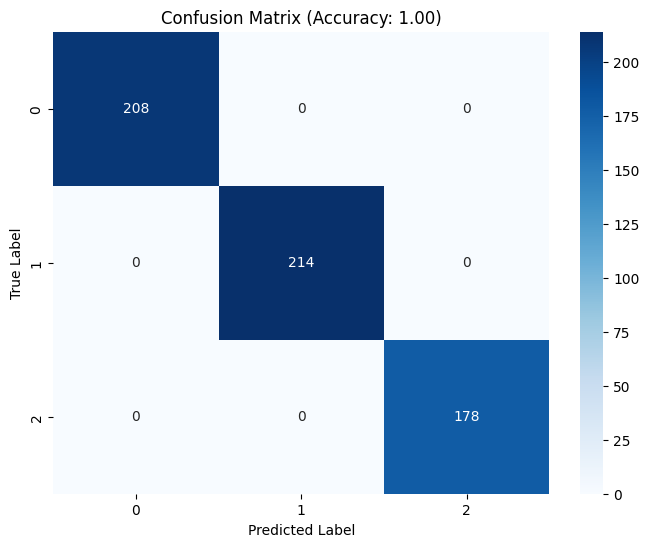

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(Y_test, pred_classes)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix')
plt.show()

/tmp/ipykernel_2063/998783992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='viridis')


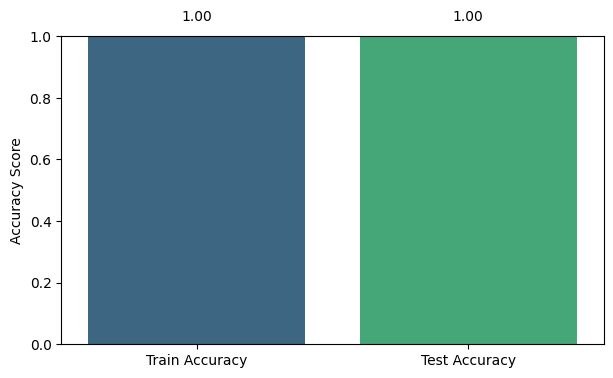

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_scores = {'Train Accuracy': at, 'Test Accuracy': a}
labels = list(accuracy_scores.keys())
values = list(accuracy_scores.values())

plt.figure(figsize=(7, 4))
sns.barplot(x=labels, y=values, palette='viridis')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
for index, value in enumerate(values):
    plt.text(index, value + 0.05, f'{value:.2f}', color='black', ha="center")
plt.show()